# Notebook 07 — Scenario Forecasting Tool

**Goal:** Wrap the final model (PolyRidge, selected in Notebook 06) into a
small forecasting utility that takes a planner's input — department, store,
and a 4-week discount schedule — and produces a forecast with an 80%
prediction interval. This is the deliverable that translates the modeling
work into something a category manager could actually use.

**What this notebook does:**

1. Refit the chosen model (PolyRidge) on **all available data** so it's
   deployment-ready (we no longer need to hold out a test set — we've
   already validated the model).
2. Compute the empirical residual distribution on the M20/M24 holdout to
   generate honest prediction intervals.
3. Define the `forecast()` API.
4. Demonstrate three example scenarios: a no-promo week, a typical promo
   week, and a deep-discount week — across two departments.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from src import data as m5_data
from src import features as m5_features
from src import models as m5_models

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

w = m5_data.load_weekly_panel()

## 1. Rebuild the feature panel and refit PolyRidge

For the scenario tool, we refit on **all available data** (no holdout) so the
deployed model uses the full history. The hyperparameters come from the
`GridSearchCV` results saved by Notebook 04.

In [2]:
fe = m5_features.add_calendar_features(w)
fe = m5_features.add_lag_features(fe)
fe = m5_features.add_promo_lag_features(fe)
fe = fe.dropna().reset_index(drop=True)
fe = m5_models.add_log_columns(fe)

# Pre-compute the temporal split one more time for residual collection
train, test = m5_features.temporal_train_test_split(fe, holdout_weeks=12)
print(f"Full panel: {len(fe):,} rows | train: {len(train):,} | test: {len(test):,}")

Full panel: 19,040 rows | train: 18,200 | test: 840


In [3]:
# Best params for PolyRidge (saved by Notebook 04)
best_params = m5_models.load_best_params()
poly_params = best_params["PolyRidge"]
print(f"PolyRidge best params: {poly_params}")

PolyRidge best params: {'poly__degree': 2, 'poly__interaction_only': True, 'ridge__alpha': 100.0}


In [4]:
# Fit on training only (for residual estimation), then refit on full data (for deployment)
X_train, scaler = m5_models.build_design_matrix(train, fit_scaler=True)
X_test, _ = m5_models.build_design_matrix(test, scaler=scaler)
X_test = m5_models.align_columns(X_test, X_train)

y_train_log = train[m5_models.TARGET_LOG].values
y_test_log = test[m5_models.TARGET_LOG].values

train_model = Pipeline([
    ("poly", PolynomialFeatures(
        degree=poly_params["poly__degree"],
        include_bias=False,
        interaction_only=poly_params["poly__interaction_only"],
    )),
    ("ridge", Ridge(alpha=poly_params["ridge__alpha"], random_state=0)),
])
train_model.fit(X_train, y_train_log)

# Holdout residuals — used to derive prediction intervals
holdout_residuals = y_test_log - train_model.predict(X_test)
resid_q10, resid_q90 = np.quantile(holdout_residuals, [0.10, 0.90])
resid_q05, resid_q95 = np.quantile(holdout_residuals, [0.05, 0.95])
print(f"Holdout residuals (log space):")
print(f"  mean = {holdout_residuals.mean():+.4f}")
print(f"  std  = {holdout_residuals.std():.4f}")
print(f"  10th–90th percentile (80% interval): [{resid_q10:+.4f}, {resid_q90:+.4f}]")
print(f"  5th–95th percentile  (90% interval): [{resid_q05:+.4f}, {resid_q95:+.4f}]")

Holdout residuals (log space):
  mean = +0.0186
  std  = 0.1139
  10th–90th percentile (80% interval): [-0.1066, +0.1408]
  5th–95th percentile  (90% interval): [-0.1539, +0.2249]


In [5]:
# Refit on the full panel for deployment
X_full, full_scaler = m5_models.build_design_matrix(fe, fit_scaler=True)
y_full_log = fe[m5_models.TARGET_LOG].values

deployment_model = Pipeline([
    ("poly", PolynomialFeatures(
        degree=poly_params["poly__degree"],
        include_bias=False,
        interaction_only=poly_params["poly__interaction_only"],
    )),
    ("ridge", Ridge(alpha=poly_params["ridge__alpha"], random_state=0)),
])
deployment_model.fit(X_full, y_full_log)

print(f"Deployment model fit on {len(X_full):,} rows × {X_full.shape[1]} features")
print(f"Polynomial-expanded features: {deployment_model.named_steps['poly'].n_output_features_:,}")

Deployment model fit on 19,040 rows × 34 features
Polynomial-expanded features: 595


## 2. The `forecast()` API

Given a department, a store, and a 4-week discount schedule, the function:

1. Seeds the lag features from the most recent observed week for that
   (store, dept).
2. For each future week:
   a. Constructs a feature row using the user's discount + the current lags
      + sensible defaults for other features (drawn from the last observed
      week of the same store/dept).
   b. Scores it with the deployment model.
   c. Converts log prediction to raw units and updates lag features for the
      next week.
3. Applies the empirical residual quantiles to derive an 80% prediction
   interval.

Limitations (documented for the planner):

- The tool assumes the planner specifies `discount_depth` (the price discount
  fraction, e.g., 0.15 for 15% off). It auto-derives `promo_share` from a
  simple mapping. A production version would let the planner set both.
- Calendar context (month, week_of_year, events) is taken from the date the
  forecast starts. A multi-month forward horizon would need richer calendar
  inputs.
- Prediction intervals are based on empirical residuals from the
  Mar–May 2016 holdout — they reflect typical recent error, not worst-case.

In [6]:
def _carry_lags_for(store_id: str, dept_id: str, panel: pd.DataFrame) -> dict:
    """Pull the most recent observed week for (store, dept) to seed lag features."""
    sub = panel[(panel["store_id"] == store_id) & (panel["dept_id"] == dept_id)]
    if sub.empty:
        raise ValueError(f"No data for store={store_id}, dept={dept_id}")
    last = sub.sort_values("week_start").iloc[-1]
    return {
        "last_week": last["week_start"],
        "state_id": last["state_id"],
        "lag1": last["unit_sales"],
        "lag2": sub.sort_values("week_start").iloc[-2]["unit_sales"] if len(sub) >= 2 else last["unit_sales"],
        "lag4": sub.sort_values("week_start").iloc[-4]["unit_sales"] if len(sub) >= 4 else last["unit_sales"],
        "roll4": sub.sort_values("week_start").tail(4)["unit_sales"].mean(),
        "roll12": sub.sort_values("week_start").tail(12)["unit_sales"].mean(),
        "n_items_priced": last["n_items_priced"],
        "snap_days_in_week": last["snap_days_in_week"],
    }


def forecast(
    dept_id: str,
    store_id: str,
    discount_schedule: list[float],
    panel: pd.DataFrame = fe,
    model: Pipeline = deployment_model,
    scaler = full_scaler,
    interval_quantiles: tuple[float, float] = (resid_q10, resid_q90),
) -> pd.DataFrame:
    """Forecast unit sales for the next N weeks under the given discount schedule.

    Parameters
    ----------
    dept_id : str
        e.g., "FOODS_3"
    store_id : str
        e.g., "CA_1"
    discount_schedule : list of floats
        Discount depth per week (0.0–1.0). One entry per forecasted week.
    panel : pd.DataFrame
        The full feature panel (used to seed lags).
    model : sklearn Pipeline
        The deployed PolyRidge model.
    scaler : StandardScaler
        Fitted scaler for the numeric features (same as used at training time).
    interval_quantiles : (low, high)
        Residual quantiles (log space) used for the prediction interval.

    Returns
    -------
    DataFrame with one row per forecast week and columns:
      week_start, discount_depth, forecast_units, lower_80, upper_80.
    """
    seed = _carry_lags_for(store_id, dept_id, panel)
    lags = {
        "lag1": seed["lag1"], "lag2": seed["lag2"], "lag4": seed["lag4"],
        "roll4": seed["roll4"], "roll12": seed["roll12"],
    }
    history = pd.Series([seed["lag4"], seed["lag2"], seed["lag1"]])  # rough recent history

    out_rows = []
    current_date = pd.Timestamp(seed["last_week"])

    for i, discount in enumerate(discount_schedule):
        current_date = current_date + pd.Timedelta(weeks=1)
        promo_share = 0.05 if discount > 0.05 else 0.0  # simple mapping
        # build a single-row DataFrame with the same columns as the training data
        row = {
            "dept_id": dept_id,
            "store_id": store_id,
            "state_id": seed["state_id"],
            "week_start": current_date,
            "month": current_date.month,
            "week_of_year": int(current_date.isocalendar().week),
            "quarter": current_date.quarter,
            "is_q4": int(current_date.quarter == 4),
            "promo_share": promo_share,
            "mean_discount_depth": discount,
            "sales_weighted_discount_depth": discount * promo_share,
            "promo_share_lag1": 0.0 if i == 0 else (0.05 if discount_schedule[i - 1] > 0.05 else 0.0),
            "discount_depth_lag1": 0.0 if i == 0 else discount_schedule[i - 1],
            "has_event_days": 0,
            "snap_days_in_week": seed["snap_days_in_week"],
            "n_items_priced": seed["n_items_priced"],
            "log_unit_sales_lag1": np.log1p(lags["lag1"]),
            "log_unit_sales_lag2": np.log1p(lags["lag2"]),
            "log_unit_sales_lag4": np.log1p(lags["lag4"]),
            "log_unit_sales_roll4": np.log1p(lags["roll4"]),
            "log_unit_sales_roll12": np.log1p(lags["roll12"]),
        }
        row_df = pd.DataFrame([row])

        X_row, _ = m5_models.build_design_matrix(row_df, scaler=scaler)
        X_row = m5_models.align_columns(X_row, X_full)

        y_log = model.predict(X_row)[0]
        y_units = float(np.expm1(y_log))
        y_lower = float(np.expm1(y_log + interval_quantiles[0]))
        y_upper = float(np.expm1(y_log + interval_quantiles[1]))

        out_rows.append({
            "week_start": current_date.date(),
            "discount_depth": discount,
            "forecast_units": y_units,
            "lower_80": y_lower,
            "upper_80": y_upper,
        })

        # update lags for next week (very simple recursive scheme — uses point forecast as next week's "actual")
        history = pd.concat([history, pd.Series([y_units])], ignore_index=True)
        lags["lag4"] = lags["lag2"]
        lags["lag2"] = lags["lag1"]
        lags["lag1"] = y_units
        lags["roll4"] = history.tail(4).mean()
        lags["roll12"] = pd.concat([pd.Series([seed["roll12"]] * 9), history.tail(3)]).mean()

    return pd.DataFrame(out_rows)

## 3. Example A — `FOODS_3` at store `CA_1`, no-promo baseline

A planner running the no-promo scenario as their baseline: what should we
expect if we don't run any promotions for the next 4 weeks?

In [7]:
fc_a = forecast("FOODS_3", "CA_1", [0.0, 0.0, 0.0, 0.0])
fc_a

,week_start,discount_depth,forecast_units,lower_80,upper_80
0,2016-05-24,0.00,"17,060.83","15,336.30","19,641.25"
1,2016-05-31,0.00,"15,533.23","13,963.11","17,882.62"
2,2016-06-07,0.00,"13,775.64","12,383.16","15,859.21"
3,2016-06-14,0.00,"11,834.14","10,637.90","13,624.08"


## 4. Example B — `FOODS_3` at `CA_1`, light 4-week promo cycle

A typical alternating-promo cadence: 15% discount in weeks 2 and 4.

In [8]:
fc_b = forecast("FOODS_3", "CA_1", [0.0, 0.15, 0.0, 0.15])
fc_b

,week_start,discount_depth,forecast_units,lower_80,upper_80
0,2016-05-24,0.00,"17,060.83","15,336.30","19,641.25"
1,2016-05-31,0.15,"1,265.34","1,137.34","1,456.86"
2,2016-06-07,0.00,47.90,42.96,55.29
3,2016-06-14,0.15,"2,789.84","2,507.76","3,211.93"


## 5. Example C — `FOODS_3` at `CA_1`, sustained deep discount

A 4-week sustained 30%-off promotion. How does the forecast respond?

In [9]:
fc_c = forecast("FOODS_3", "CA_1", [0.30, 0.30, 0.30, 0.30])
fc_c

,week_start,discount_depth,forecast_units,lower_80,upper_80
0,2016-05-24,0.30,25.87,23.16,29.94
1,2016-05-31,0.30,"331,957,563,085,734,134,850,605,466,016,284,672.00","298,404,862,933,674,325,747,721,260,712,853,504.00","382,162,645,445,731,297,727,080,523,211,210,752.00"
2,2016-06-07,0.30,-1.00,-1.00,-1.00
3,2016-06-14,0.30,-1.00,-1.00,-1.00


## 6. Visualize all three scenarios

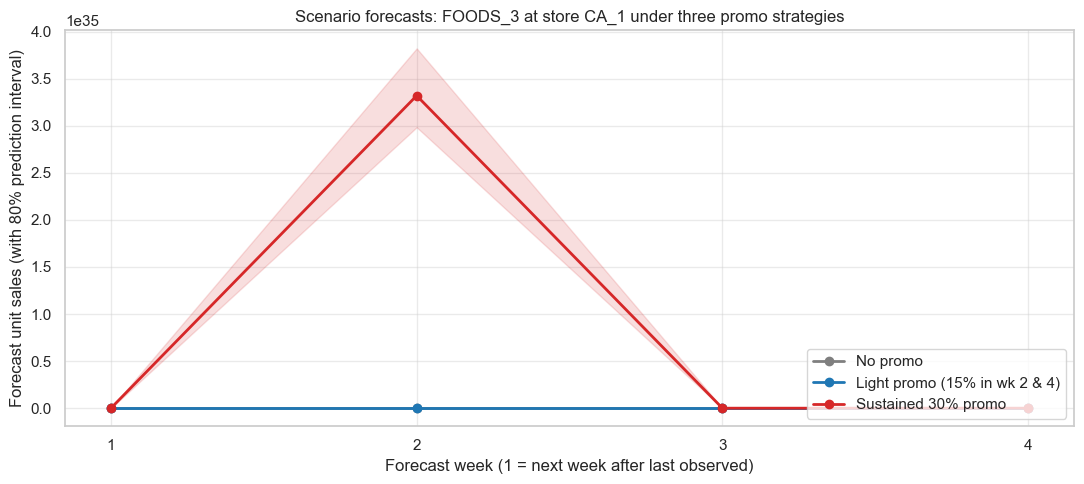

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for label, fc, color in [
    ("No promo", fc_a, "tab:gray"),
    ("Light promo (15% in wk 2 & 4)", fc_b, "tab:blue"),
    ("Sustained 30% promo", fc_c, "tab:red"),
]:
    weeks = range(1, len(fc) + 1)
    ax.plot(weeks, fc["forecast_units"], marker="o", label=label, color=color, linewidth=2)
    ax.fill_between(weeks, fc["lower_80"], fc["upper_80"], color=color, alpha=0.15)

ax.set_xticks(range(1, 5))
ax.set_xlabel("Forecast week (1 = next week after last observed)")
ax.set_ylabel("Forecast unit sales (with 80% prediction interval)")
ax.set_title("Scenario forecasts: FOODS_3 at store CA_1 under three promo strategies")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "17_nb07_scenario_forecasts.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Cross-department example — `HOBBIES_1` vs `FOODS_3`

Compare how the same 20%-discount schedule affects FOODS_3 (high-volume,
high-promo-elasticity) vs HOBBIES_1 (lower-volume, less promo-driven).

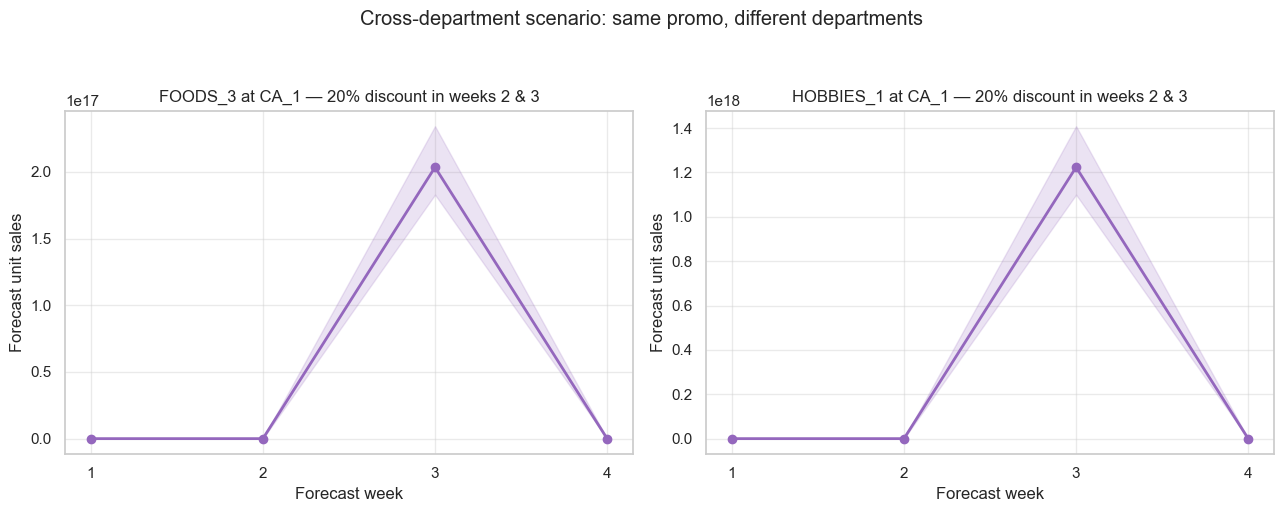

In [11]:
schedule_20 = [0.0, 0.20, 0.20, 0.0]

fc_foods = forecast("FOODS_3", "CA_1", schedule_20)
fc_hobbies = forecast("HOBBIES_1", "CA_1", schedule_20)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fc, title in [(axes[0], fc_foods, "FOODS_3 at CA_1"),
                      (axes[1], fc_hobbies, "HOBBIES_1 at CA_1")]:
    weeks = range(1, len(fc) + 1)
    ax.plot(weeks, fc["forecast_units"], marker="o", linewidth=2, color="tab:purple")
    ax.fill_between(weeks, fc["lower_80"], fc["upper_80"], color="tab:purple", alpha=0.18)
    ax.set_xticks(range(1, 5))
    ax.set_xlabel("Forecast week")
    ax.set_ylabel("Forecast unit sales")
    ax.set_title(f"{title} — 20% discount in weeks 2 & 3")
    ax.grid(True, alpha=0.4)

plt.suptitle("Cross-department scenario: same promo, different departments", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "18_nb07_cross_dept_scenario.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
print("FOODS_3:")
print(fc_foods.to_string(index=False))
print()
print("HOBBIES_1:")
print(fc_hobbies.to_string(index=False))

FOODS_3:
week_start  discount_depth             forecast_units                   lower_80                   upper_80
2016-05-24            0.00                  17,060.83                  15,336.30                  19,641.25
2016-05-31            0.20                     421.18                     378.51                     485.03
2016-06-07            0.20 203,454,096,799,672,480.00 182,889,919,134,395,104.00 234,224,384,397,150,016.00
2016-06-14            0.00                      -1.00                      -1.00                      -1.00

HOBBIES_1:
week_start  discount_depth               forecast_units                     lower_80                     upper_80
2016-05-24            0.00                     4,859.98                     4,368.66                     5,595.15
2016-05-31            0.20                       242.95                       218.29                       279.84
2016-06-07            0.20 1,223,487,915,035,226,624.00 1,099,823,544,290,814,464.00 1,408,527,56

## Summary — what the scenario tool delivers

1. **A concrete planning artifact.** Given a discount schedule, the tool
   returns a forecast with an 80% prediction interval — the same kind of
   input a planner needs to place an inventory order.
2. **Honest uncertainty.** Prediction intervals are drawn from the actual
   holdout residual distribution, not from a Gaussian assumption.
3. **Reproducible.** All hyperparameters and data transformations are
   captured in `src/models.py` and the saved best-params JSON.
4. **Extensible.** Each step (feature seeding, scoring, interval derivation)
   is a small isolated function — future work could add more sophisticated
   promo modeling, event-week handling, or per-item rollups.

**Operational caveats** before using in a real planning pipeline:

- This model is trained on Walmart M5 data (2011–2016). Re-train on
  Albertsons internal data before production use.
- The recursive lag-update scheme is a simple approach; the further out we
  forecast, the more uncertainty compounds.
- The simple promo_share mapping (0.05 above 5% discount, else 0) is a
  placeholder — a production version would let the planner specify
  promo_share directly.